In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix

**Dataset:** Synthetic Kaggle dataset, 1200 rows, 13 columns covering demographics, 
social media habits, sleep, academic performance, and mental health indicators.

In [ ]:
df = pd.read_csv('Teen_Mental_Health_Dataset.csv')

**Goal:** Explore the dataset, check data quality, understand distributions and 
relationships between variables, and build a decision tree to classify `depression_label`

In [3]:
df.describe()

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,15.928333,4.536667,6.449417,1.740333,2.990383,1.014500,5.445833,5.636667,5.565000,0.025833
std,2.021947,2.029599,1.442677,0.716660,0.576758,0.582185,2.903290,2.859453,2.830627,0.158704
min,13.000000,1.000000,4.000000,0.500000,2.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,14.000000,2.800000,5.200000,1.100000,2.500000,0.500000,3.000000,3.000000,3.000000,0.000000
50%,16.000000,4.500000,6.500000,1.800000,2.990000,1.000000,5.000000,6.000000,6.000000,0.000000
75%,18.000000,6.300000,7.600000,2.400000,3.480000,1.500000,8.000000,8.000000,8.000000,0.000000
max,19.000000,8.000000,9.000000,3.000000,4.000000,2.000000,10.000000,10.000000,10.000000,1.000000


No missing values or duplicates were found in the dataset (checked separately with 
`df.isnull().sum()` and `df.duplicated().sum()`), so no imputation or cleaning was required

In [4]:
print(df.min())

age                             13
gender                      female
daily_social_media_hours       1.0
platform_usage                Both
sleep_hours                    4.0
screen_time_before_sleep       0.5
academic_performance           2.0
physical_activity              0.0
social_interaction_level      high
stress_level                     1
anxiety_level                    1
addiction_level                  1
depression_label                 0
dtype: object


## Gender Balance
Checked using `value_counts(normalize=True)` — gender distribution is reasonably 
balanced between categories, so no class imbalance concern here.

<Axes: xlabel='gender'>

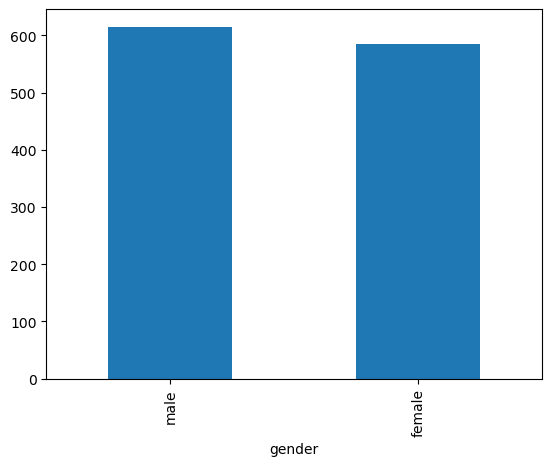

In [5]:
df['gender'].value_counts().plot(kind='bar')

## Platform Usage
`platform_usage` has 3 categories: Instagram, TikTok, and Both. Checked distribution 
using `value_counts()` to see which platform is most common among respondents.

In [6]:
df['platform_usage'].max()

'TikTok'

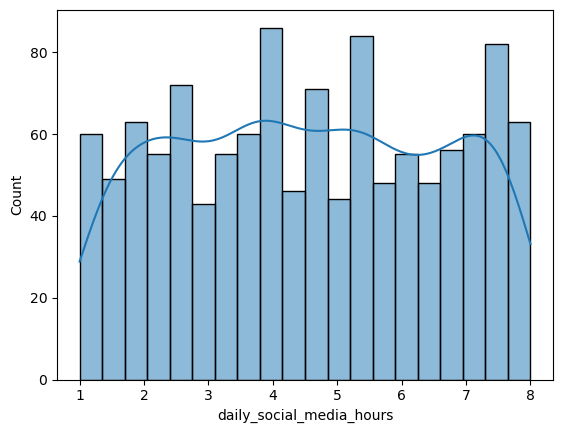

In [7]:
import seaborn as sns
sns.histplot(df['daily_social_media_hours'] , kde=True ,bins=20)
plt.show()

In [8]:
print(df['daily_social_media_hours'].skew())

0.009171936380806024


From the histogram , it is concluded that the distribution of , daily_social_media_hours is normal and not skewed in our dataset

## Distribution of daily_social_media_hours
Skew ≈ 0.009 (essentially symmetric), but the histogram shows values spread fairly 
evenly across the 1–8 hour range rather than clustering around a central peak. 
This indicates a **uniform distribution**, not a normal (bell-curve) one — a skew 
value near zero only confirms symmetry, not bell-shape. No transformation needed 
before modeling, and this isn't relevant for the decision tree regardless, since 
trees don't require any distributional assumptions on features.

<Axes: xlabel='depression_label', ylabel='Count'>

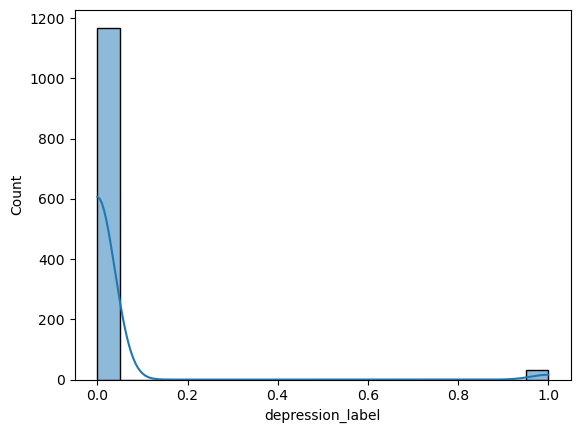

In [9]:
sns.histplot(df['depression_label'] , kde=True ,bins=20)

In [10]:
print(df['depression_label'].value_counts())


depression_label
0    1169
1      31
Name: count, dtype: int64


In [11]:
matrix = df.corr(numeric_only=True)
matrix

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label
age,1.000000,-0.006635,0.001530,0.075612,-0.013973,0.011086,-0.031208,0.026363,0.038265,0.010973
daily_social_media_hours,-0.006635,1.000000,-0.009472,0.035777,0.013179,0.025546,0.030698,0.027835,-0.024964,0.175201
sleep_hours,0.001530,-0.009472,1.000000,0.010235,0.021866,0.012701,-0.010979,-0.011879,-0.054838,-0.190630
screen_time_before_sleep,0.075612,0.035777,0.010235,1.000000,-0.034715,-0.026450,-0.008650,-0.010344,0.028884,-0.016502
academic_performance,-0.013973,0.013179,0.021866,-0.034715,1.000000,0.023312,-0.000600,-0.064379,0.029354,0.001441
physical_activity,0.011086,0.025546,0.012701,-0.026450,0.023312,1.000000,0.012159,-0.022233,0.026200,-0.017598
stress_level,-0.031208,0.030698,-0.010979,-0.008650,-0.000600,0.012159,1.000000,0.015811,-0.000129,0.170474
anxiety_level,0.026363,0.027835,-0.011879,-0.010344,-0.064379,-0.022233,0.015811,1.000000,0.031154,0.169566
addiction_level,0.038265,-0.024964,-0.054838,0.028884,0.029354,0.026200,-0.000129,0.031154,1.000000,-0.013952
depression_label,0.010973,0.175201,-0.190630,-0.016502,0.001441,-0.017598,0.170474,0.169566,-0.013952,1.000000


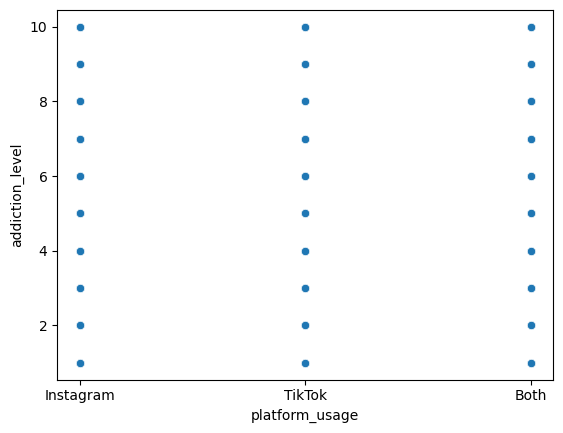

In [12]:
sns.scatterplot(x='platform_usage',y='addiction_level',data=df)
plt.show()

In [13]:
df.groupby('platform_usage')['addiction_level'].mean()

platform_usage
Both         5.496164
Instagram    5.581509
TikTok       5.615578
Name: addiction_level, dtype: float64

In [14]:
df.groupby('platform_usage')['stress_level'].mean()

platform_usage
Both         5.549872
Instagram    5.498783
TikTok       5.288945
Name: stress_level, dtype: float64

In [15]:
#Ordinal Mapping for social_interaction_level : because here we have an order low , medium and high so , 1,2,3 are accurate 
order_map={'low':0 ,'medium':1 ,'high':2}
df['social_interaction_level'] = df['social_interaction_level'].str.strip().str.lower().map(order_map)
df['social_interaction_level'].head(5)

0    0
1    2
2    2
3    1
4    1
Name: social_interaction_level, dtype: int64

## Encoding social_interaction_level
`social_interaction_level` (low/medium/high) is an **ordinal** categorical variable — 
it has a natural order. Rather than one-hot encoding (which would discard that order), 
it was mapped directly to `{low: 0, medium: 1, high: 2}` to preserve the ranking for 
any model that might use it.

In [16]:
print(df['social_interaction_level'].unique())

[0 2 1]


## Feature Selection & Data Leakage Investigation

An initial decision tree was trained using **all 12 features**, which produced a 
**perfect classification score (accuracy, precision, and recall all = 1.00)** on 
unseen test data. A perfect score on real-world behavioral data is a red flag rather 
than a success — it usually signals **data leakage**, where one or more features are 
so tightly tied to the target that the model isn't learning a genuine pattern.

Feature importance from that first model showed only 4 variables were driving the 
result: `stress_level`, `sleep_hours`, `anxiety_level`, and `daily_social_media_hours` 
— all other 8 features (including `addiction_level`) had zero importance.

**Diagnostic test:** Removing those 4 features and retraining on the remaining 8 
caused recall on the depression class to collapse to 0.00 (missed every real case), 
despite accuracy staying high (0.88) due to class imbalance. This confirmed the 
predictive power was concentrated almost entirely in those 4 variables — likely 
reflecting how `depression_label` was synthetically generated in this dataset, rather 
than a broad, realistic relationship across all lifestyle factors.

**Final approach:** The model below uses `stress_level`, `sleep_hours`, and 
`anxiety_level` only (dropping `daily_social_media_hours`, the weakest of the four), 
which produces a more realistic, imperfect result — useful evidence that these 3 
variables carry real signal without the model achieving a suspiciously perfect fit.

In [17]:
X = df[['stress_level', 'sleep_hours', 'anxiety_level']]
y = df['depression_label']

print(X.head())
print(X.shape)

   stress_level  sleep_hours  anxiety_level
0             2          7.4              2
1             8          8.0              1
2             2          7.6              4
3             1          6.9              7
4             3          4.9              5
(1200, 3)


In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(y_train.value_counts())
print(y_test.value_counts())

depression_label
0    935
1     25
Name: count, dtype: int64
depression_label
0    234
1      6
Name: count, dtype: int64


In [19]:
model = DecisionTreeClassifier(class_weight='balanced',max_depth=10,min_samples_leaf=15,random_state=42)
model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,15
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


In [20]:
y_pred = model.predict(X_test)

In [21]:
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[227   7]
 [  0   6]]
              precision    recall  f1-score   support

           0       1.00      0.97      0.98       234
           1       0.46      1.00      0.63         6

    accuracy                           0.97       240
   macro avg       0.73      0.99      0.81       240
weighted avg       0.99      0.97      0.98       240



In [22]:
importance = pd.Series(model.feature_importances_, index=X_train.columns)
print(importance.sort_values(ascending=False))

stress_level     0.492970
sleep_hours      0.332713
anxiety_level    0.174317
dtype: float64


## Feature Importance (Final Model)
- stress_level: 0.49
- sleep_hours: 0.33
- anxiety_level: 0.17

`stress_level` and `sleep_hours` together account for ~83% of the model's 
decision-making, with `anxiety_level` playing a smaller supporting role.

In [25]:
from sklearn.metrics import accuracy_score , classification_report
print(accuracy_score(y_test, y_pred))

0.9708333333333333
